# Sesión 20 · Seaborn: explora distribuciones y relaciones

Badge 4 · Visualización y narrativa de datos

Relaciona columnas con variables visuales y distingue observaciones de estimaciones.

150 minutos de clase y 45–60 minutos de tarea. Ejecuta en orden.

## Distribuciones: observa antes de resumir

Seaborn trabaja naturalmente con tablas en formato largo. data indica el DataFrame y x, y, hue y col nombran variables. hue separa grupos mediante color; incluye leyenda y categorías comprensibles.

Un histograma cuenta observaciones dentro de intervalos. Una caja resume mediana y cuartiles, pero puede ocultar el tamaño y la forma de una muestra pequeña. Superponer puntos permite mostrar las observaciones reales.

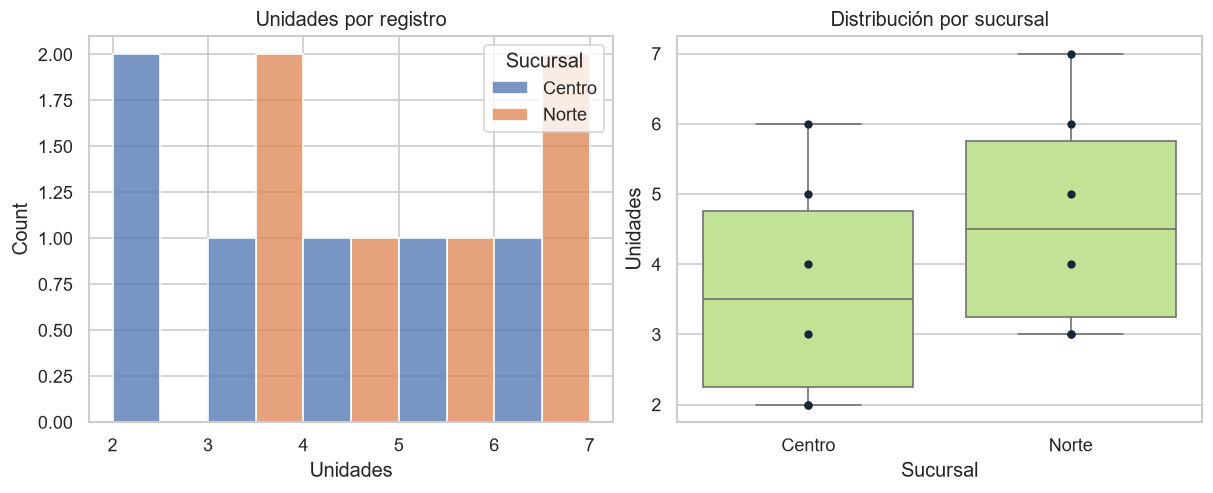

In [1]:
import pandas as pd
datos = pd.DataFrame({
    "Sucursal": ["Centro"]*6 + ["Norte"]*6,
    "Producto": ["A", "B", "C"]*4,
    "Unidades": [2, 4, 3, 5, 2, 6, 3, 5, 4, 6, 3, 7],
    "Precio": [100, 200, 150]*4
})
datos["Ingreso"] = datos["Unidades"] * datos["Precio"]
import seaborn as sns
import matplotlib.pyplot as plt
sns.set_theme(style="whitegrid")
fig,ax=plt.subplots(1,2,figsize=(10,4),layout="constrained")
sns.histplot(data=datos,x="Unidades",hue="Sucursal",multiple="dodge",binwidth=1,ax=ax[0])
sns.boxplot(data=datos,x="Sucursal",y="Unidades",color="#c4ef88",ax=ax[1])
sns.stripplot(data=datos,x="Sucursal",y="Unidades",color="#182638",jitter=False,ax=ax[1])
ax[0].set_title("Unidades por registro");ax[1].set_title("Distribución por sucursal")
plt.show()

**Qué observar:** Se muestran 12 registros. La caja y los puntos permiten comparar ambas sucursales sin ocultar observaciones.

**Recuerda:** Con pocos datos, una curva de densidad puede aparentar más evidencia de la disponible.

## barplot agrega; scatterplot muestra pares

barplot calcula una estimación por categoría: de forma predeterminada, una media. No lo confundas con el total de una columna. Si quieres ingresos totales, agrupa de manera explícita o indica el estimador que corresponde.

Las barras de error representan una definición de incertidumbre o dispersión, no decoración. En este ejemplo mostramos totales exactos del conjunto de práctica, por lo que desactivamos el intervalo con errorbar=None y lo explicamos.

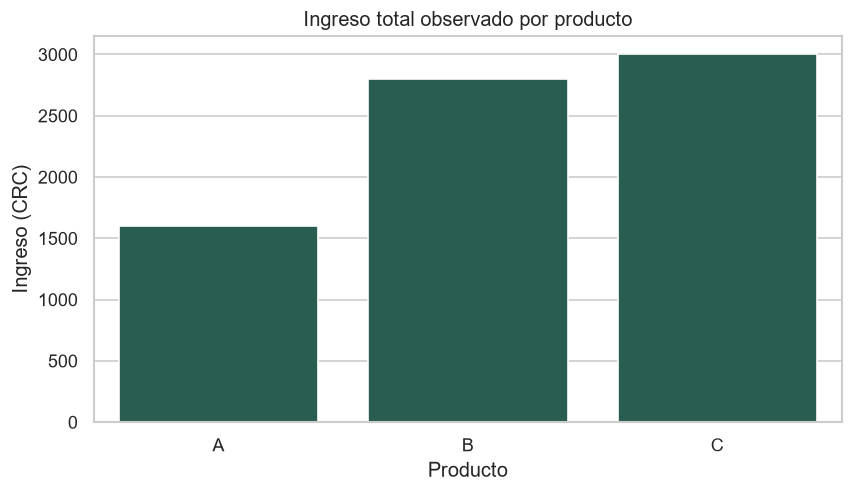

In [2]:
import pandas as pd
datos = pd.DataFrame({
    "Sucursal": ["Centro"]*6 + ["Norte"]*6,
    "Producto": ["A", "B", "C"]*4,
    "Unidades": [2, 4, 3, 5, 2, 6, 3, 5, 4, 6, 3, 7],
    "Precio": [100, 200, 150]*4
})
datos["Ingreso"] = datos["Unidades"] * datos["Precio"]
import seaborn as sns
import matplotlib.pyplot as plt
r=datos.groupby("Producto",as_index=False).Ingreso.sum()
fig,ax=plt.subplots(figsize=(7,4),layout="constrained")
sns.barplot(data=r,x="Producto",y="Ingreso",errorbar=None,color="#216556",ax=ax)
ax.set(title="Ingreso total observado por producto",ylabel="Ingreso (CRC)")
plt.show()

**Qué observar:** Los totales son 1600, 2800 y 3000 CRC; no son promedios por registro.

**Recuerda:** Antes de interpretar cualquier barra, identifica qué se está agregando y qué representa su intervalo.

## Funciones por eje y funciones por figura

scatterplot, histplot y boxplot aceptan ax para integrarse en una figura Matplotlib. relplot, displot y catplot administran su propia figura y permiten dividir en facetas.

Usa facetas para comparar grupos con la misma escala. No añadas demasiadas categorías: el tamaño de cada panel debe seguir permitiendo leer datos, etiquetas y leyendas.

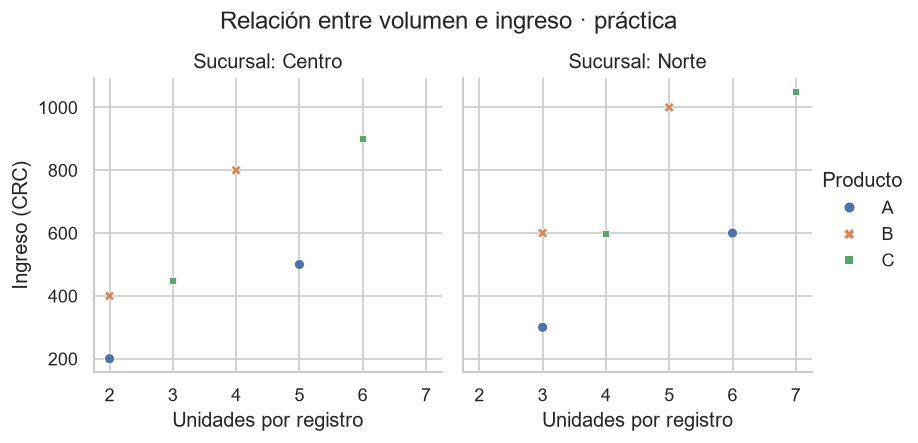

In [3]:
import pandas as pd
datos = pd.DataFrame({
    "Sucursal": ["Centro"]*6 + ["Norte"]*6,
    "Producto": ["A", "B", "C"]*4,
    "Unidades": [2, 4, 3, 5, 2, 6, 3, 5, 4, 6, 3, 7],
    "Precio": [100, 200, 150]*4
})
datos["Ingreso"] = datos["Unidades"] * datos["Precio"]
import seaborn as sns
import matplotlib.pyplot as plt
g=sns.relplot(data=datos,x="Unidades",y="Ingreso",hue="Producto",style="Producto",col="Sucursal",height=3.5,aspect=1)
g.set_axis_labels("Unidades por registro","Ingreso (CRC)")
g.set_titles("Sucursal: {col_name}")
g.figure.suptitle("Relación entre volumen e ingreso · práctica",y=1.05)
plt.show()

**Qué observar:** Una faceta por sucursal muestra cada venta como un punto. Producto se distingue por color y forma.

**Recuerda:** La relación entre unidades e ingreso es parcialmente mecánica: Ingreso = Precio × Unidades; no prueba un efecto causal.

## Reto · Comparación visible

Compara unidades por sucursal usando boxplot y puntos.

**Criterio:** Las 12 observaciones aparecen junto al resumen.

In [ ]:
# Tu solución aquí.

## Reto · Controla el resumen

Grafica ingreso total por sucursal y desactiva intervalos que no corresponden.

**Criterio:** Centro suma 3250 CRC; Norte suma 4150 CRC.

In [ ]:
# Tu solución aquí.

## Tarea · Laboratorio · Seaborn estadístico

Relaciona columnas con variables visuales y distingue observaciones de estimaciones.

1. Usa los datos de práctica o ventas_proyecto.csv ya limpio.
2. Compara dos distribuciones con cajas y puntos.
3. Crea un gráfico con facetas y explica hue, col y escalas.
4. Describe si cada gráfico muestra datos individuales, conteos o estimaciones.

In [ ]:
# Desarrolla tu tarea y explica los resultados.